# VOC 2007: preliminary EDA for the A2 dataset proposal

**Group:** G-M10  
**EDA owner:** Nguyễn Hữu Cầu  
**Proposal coordinator:** Trần Gia Lâm

This notebook downloads the official VOC 2007 trainval release, audits images and XML annotations,
creates a proposed image-level split, and exports evidence for the proposal.
It does not train a model or inspect the official test set. A CPU Colab runtime is sufficient.
Main experiments require instructor approval.

Run the cells in order. Download the results ZIP and then use **File → Download → Download .ipynb**
to save this notebook with its outputs. Both files must be returned to Lâm.

The distributed notebook has no saved dataset results. Its code must be run and reviewed before
any computed number is included in a report.


## 1. Settings and environment

Use the default settings for the first run. If automatic download fails, download the official TAR
from the source link, upload it using Colab's Files panel, and set MANUAL_ARCHIVE_PATH to its path.
Do not upload the original dataset to the course GitHub repository.


In [1]:
!pip install iterative-stratification scikit-learn

In [2]:
from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict
import hashlib
import importlib.metadata
import json
import math
import platform
import random
import re
import shutil
import sys
import tarfile
import time
import urllib.request
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string(index=False) if hasattr(value, "to_string") else value)

SEED = 42
TRAIN_FRACTION = 0.80
CHECK_NEAR_DUPLICATES = True
NEAR_DUPLICATE_MAX_DISTANCE = 4
MANUAL_ARCHIVE_PATH = ""  # Example: /content/VOCtrainval_06-Nov-2007.tar
EXPECTED_TRAINVAL_IMAGES = 5011

BASE = Path("/content") if Path("/content").exists() else Path.cwd()
DATA_DIR = BASE / "data/a2_voc2007"
VOC_ROOT = DATA_DIR / "VOCdevkit/VOC2007"
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUT = BASE / "outputs/a2_eda" / RUN_ID
for directory in [DATA_DIR, OUT / "tables", OUT / "figures", OUT / "splits"]:
    directory.mkdir(parents=True, exist_ok=True)

DATA_URL = "https://thor.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar"
ARCHIVE_NAME = "VOCtrainval_06-Nov-2007.tar"
EXPECTED_MD5 = "c52e279531787c972589f7e41ab4ae64"
CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat", "chair",
    "cow", "diningtable", "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]
CLASS_TO_ID = {name: i + 1 for i, name in enumerate(CLASSES)}
SOURCES = {
    "dataset": "https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/",
    "published_statistics": "https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/dbstats.html",
    "annotation_and_evaluation": "https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/htmldoc/index.html",
    "archive_and_checksum": "https://docs.pytorch.org/vision/stable/_modules/torchvision/datasets/voc.html"
}
environment = {
    "run_id": RUN_ID, "started_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version, "platform": platform.platform(), "seed": SEED,
    "packages": {p: importlib.metadata.version(p) for p in ["numpy", "pandas", "matplotlib", "Pillow"]},
    "gpu_required": False, "main_training_performed": False,
}
(OUT / "environment.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
(OUT / "class_mapping.json").write_text(json.dumps({"background": 0, **CLASS_TO_ID}, indent=2), encoding="utf-8")
print("Output folder:", OUT)
print("No GPU is needed for this notebook.")


Output folder: /content/outputs/a2_eda/20261006T225426_686818Z
No GPU is needed for this notebook.


## 2. Download and verify the original archive

The download is approximately 450 MB according to the publisher. The archive filename, URL and MD5
are checked against Torchvision's dataset source. The MD5 is an integrity check for the downloaded
release, not a license statement. Only regular files and directories inside VOCdevkit/VOC2007 are extracted.


In [3]:
def file_digest(path, algorithm="sha256"):
    h = hashlib.new(algorithm)
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def download_archive(url, destination):
    partial = destination.with_suffix(destination.suffix + ".part")
    request = urllib.request.Request(url, headers={"User-Agent": "VOC2007-course-EDA"})
    downloaded = 0
    last_report = 0
    try:
        with urllib.request.urlopen(request, timeout=60) as response, partial.open("wb") as handle:
            while True:
                block = response.read(1024 * 1024)
                if not block:
                    break
                handle.write(block)
                downloaded += len(block)
                if downloaded - last_report >= 50 * 1024 * 1024:
                    print(f"Downloaded {downloaded / 1024**2:.0f} MiB")
                    last_report = downloaded
        partial.replace(destination)
    except Exception as error:
        if partial.exists():
            partial.unlink()
        raise RuntimeError(
            "Download failed. Download the same official TAR in your browser, upload it through "
            "Colab Files, set MANUAL_ARCHIVE_PATH in cell 1, and rerun from cell 1. "
            "Do not substitute a different dataset release."
        ) from error

def extract_official_archive(archive_path, destination):
    with tarfile.open(archive_path, "r:*") as archive:
        members = archive.getmembers()
        for member in members:
            parts = Path(member.name).parts
            if (Path(member.name).is_absolute() or ".." in parts
                or not parts or parts[0] != "VOCdevkit"
                or (len(parts) > 1 and parts[1] != "VOC2007")
                or not (member.isdir() or member.isfile())):
                raise ValueError(f"Unexpected archive member: {member.name}")
        for member in members:
            target = destination / member.name
            if member.isdir():
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with archive.extractfile(member) as source, target.open("wb") as output:
                    shutil.copyfileobj(source, output)

archive_path = Path(MANUAL_ARCHIVE_PATH) if MANUAL_ARCHIVE_PATH else DATA_DIR / ARCHIVE_NAME
if MANUAL_ARCHIVE_PATH and not archive_path.is_file():
    raise FileNotFoundError(f"Manual archive not found: {archive_path}")
if not archive_path.exists():
    download_archive(DATA_URL, archive_path)
actual_md5 = file_digest(archive_path, "md5")
if actual_md5 != EXPECTED_MD5:
    raise ValueError(
        f"Archive checksum mismatch: {actual_md5}. Expected {EXPECTED_MD5}. "
        "Remove the failed download and download the official archive again."
    )
extract_official_archive(archive_path, DATA_DIR)
source_record = {
    "dataset": "PASCAL VOC 2007", "release": ARCHIVE_NAME, "url": DATA_URL,
    "archive_bytes": archive_path.stat().st_size, "md5": actual_md5,
    "sha256": file_digest(archive_path), "reference_urls": SOURCES,
    "license_note": "Use the publisher's Database Rights statement and applicable image terms. "
                    "No blanket MIT or CC-BY license is asserted for this dataset.",
    "test_set_downloaded_by_this_notebook": False,
}
(OUT / "data_source.json").write_text(json.dumps(source_record, indent=2), encoding="utf-8")
print("Archive verified and extracted:", VOC_ROOT)


Downloaded 50 MiB
Downloaded 100 MiB
Downloaded 150 MiB
Downloaded 200 MiB
Downloaded 250 MiB
Downloaded 300 MiB
Downloaded 350 MiB
Downloaded 400 MiB
Archive verified and extracted: /content/data/a2_voc2007/VOCdevkit/VOC2007


## 3. Audit images and XML annotations

VOC bounding boxes use one-based inclusive coordinates. Here, width = xmax - xmin + 1 and
height = ymax - ymin + 1. Relative box area is box area divided by original image area.
We keep all annotated objects in the audit and count difficult/non-difficult objects separately.
Invalid annotations are reported; the source XML files are not edited.

Exact duplicates are checked using decoded RGB pixels plus image dimensions. The check catches identical
image content even when the JPEG file bytes differ. It does not prove that different photos show different scenes.


In [4]:
def read_ids(name):
    path = VOC_ROOT / "ImageSets/Main" / f"{name}.txt"
    ids = [line.strip() for line in path.read_text().splitlines() if line.strip()]
    if len(ids) != len(set(ids)) or any(not re.fullmatch(r"[0-9]{6}", x) for x in ids):
        raise ValueError(f"Unexpected or repeated image identifiers in {path}")
    return ids

official_train_ids = read_ids("train")
official_val_ids = read_ids("val")
trainval_ids = sorted(read_ids("trainval"))
assert set(official_train_ids).isdisjoint(official_val_ids)
assert set(trainval_ids) == set(official_train_ids) | set(official_val_ids)
assert len(trainval_ids) == EXPECTED_TRAINVAL_IMAGES, "Unexpected release or image count."

def difference_hash(rgb):
    pixels = np.asarray(rgb.convert("L").resize((9, 8), Image.Resampling.LANCZOS))
    bits = pixels[:, 1:] > pixels[:, :-1]
    return int.from_bytes(np.packbits(bits).tobytes(), "big")

def audit_image(image_id):
    xml_path = VOC_ROOT / "Annotations" / f"{image_id}.xml"
    image_path = VOC_ROOT / "JPEGImages" / f"{image_id}.jpg"
    root = ET.parse(xml_path).getroot()
    with Image.open(image_path) as image:
        original_mode = image.mode
        rgb = image.convert("RGB")
        rgb.load()
        width, height = rgb.size
        pixel_hash = hashlib.sha256(
            f"{width}x{height}:RGB:".encode() + rgb.tobytes()
        ).hexdigest()
        dhash = difference_hash(rgb)
    xml_width = int(root.findtext("size/width"))
    xml_height = int(root.findtext("size/height"))
    issues = []
    if (width, height) != (xml_width, xml_height):
        issues.append({"image_id": image_id, "object_index": -1, "issue": "image_xml_dimension_mismatch"})
    image_record = {
        "image_id": image_id, "width": width, "height": height, "mode": original_mode,
        "image_aspect_ratio": width / height, "pixel_sha256": pixel_hash,
        "dhash_hex": f"{dhash:016x}",
        "official_split": "train" if image_id in official_train_set else "val",
    }
    objects = []
    for index, obj in enumerate(root.findall("object")):
        name = obj.findtext("name", "").strip()
        difficult = int(obj.findtext("difficult", "0"))
        truncated = int(obj.findtext("truncated", "0"))
        coords = [int(obj.findtext(f"bndbox/{key}")) for key in ["xmin", "ymin", "xmax", "ymax"]]
        xmin, ymin, xmax, ymax = coords
        valid_box = 1 <= xmin <= xmax <= width and 1 <= ymin <= ymax <= height
        known_class = name in CLASS_TO_ID
        flags_valid = difficult in [0, 1] and truncated in [0, 1]
        box_width, box_height = xmax - xmin + 1, ymax - ymin + 1
        box_area = box_width * box_height if valid_box else float("nan")
        for condition, issue in [(not valid_box, "invalid_box"), (not known_class, "unknown_class"),
                                 (not flags_valid, "invalid_annotation_flag")]:
            if condition:
                issues.append({"image_id": image_id, "object_index": index, "issue": issue})
        objects.append({
            "image_id": image_id, "object_index": index, "class_name": name,
            "difficult": difficult, "truncated": truncated,
            "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax,
            "box_width": box_width, "box_height": box_height, "box_area": box_area,
            "relative_box_area": box_area / (width * height),
            "box_aspect_ratio": box_width / box_height if valid_box else float("nan"),
            "valid_box": valid_box, "known_class": known_class,
            "usable_non_difficult": valid_box and known_class and flags_valid and difficult == 0,
        })
    return image_record, objects, issues

official_train_set = set(official_train_ids)
image_records, object_records, issues, failures = [], [], [], []
for i, image_id in enumerate(trainval_ids, start=1):
    try:
        image_record, objects, found_issues = audit_image(image_id)
        image_records.append(image_record)
        object_records.extend(objects)
        issues.extend(found_issues)
    except Exception as error:
        failures.append({"image_id": image_id, "error": repr(error)})
    if i % 1000 == 0 or i == len(trainval_ids):
        print(f"Audited {i}/{len(trainval_ids)} images")

pd.DataFrame(failures, columns=["image_id", "error"]).to_csv(OUT / "tables/file_failures.csv", index=False)
issues_df = pd.DataFrame(issues, columns=["image_id", "object_index", "issue"])
issues_df.to_csv(OUT / "tables/annotation_issues.csv", index=False)
if failures:
    raise RuntimeError("Unreadable or missing files found. Review tables/file_failures.csv before continuing.")
images_df = pd.DataFrame(image_records)
objects_df = pd.DataFrame(object_records)
print("Decoded images:", len(images_df), "| XML object entries:", len(objects_df))
print("Annotation issues:", len(issues_df))


Audited 1000/5011 images
Audited 2000/5011 images
Audited 3000/5011 images
Audited 4000/5011 images
Audited 5000/5011 images
Audited 5011/5011 images
Decoded images: 5011 | XML object entries: 15662
Annotation issues: 0


## 4. Create a proposed split and check duplicate candidates

The planned split is approximately 80% training / 20% validation from the official trainval pool.
With 5,011 images and no grouping constraint that changes the count, the target is 4,009 / 1,002.
Exact duplicate groups stay in one split. Group order is shuffled with seed 42. This is a grouped
random split, not a claim of multilabel stratification; class coverage is checked below.

The perceptual hash check produces **candidates**, not confirmed duplicate labels.
Review cross-split candidates before treating the split as final. Near-duplicate or same-scene images
may need to be grouped together, followed by regenerating the split and all dependent statistics.
The official test set remains untouched; train/test overlap auditing is still required before main training.


In [5]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
def assign_iterative_stratified_split(images_df, objects_df, train_fraction, seed):
    groups = images_df.groupby("pixel_sha256", sort=True)
    group_hashes = []
    group_labels = []

    for group_hash, group_data in groups:
        img_ids_in_group = group_data.image_id.tolist()

        classes_in_group = objects_df[
            objects_df.image_id.isin(img_ids_in_group) & objects_df.usable_non_difficult
        ].class_name.unique().tolist()

        group_hashes.append(group_hash)
        group_labels.append(classes_in_group)
    mlb = MultiLabelBinarizer(classes=CLASSES)
    y_group = mlb.fit_transform(group_labels)
    X_group = np.array(group_hashes)
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=1.0 - train_fraction, random_state=seed)

    train_group_hashes, val_group_hashes = [], []
    for train_index, val_index in msss.split(X_group, y_group):
        train_group_hashes = X_group[train_index]
        val_group_hashes = X_group[val_index]
    train_ids = images_df[images_df.pixel_sha256.isin(train_group_hashes)].image_id.tolist()
    val_ids = images_df[images_df.pixel_sha256.isin(val_group_hashes)].image_id.tolist()

    target_train = round(len(images_df) * train_fraction)
    return sorted(train_ids), sorted(val_ids), target_train
train_ids, val_ids, target_train_count = assign_iterative_stratified_split(
    images_df, objects_df, TRAIN_FRACTION, SEED
)

train_id_set, val_id_set = set(train_ids), set(val_ids)
assert train_id_set.isdisjoint(val_id_set)
assert train_id_set | val_id_set == set(trainval_ids)
images_df["proposed_split"] = images_df.image_id.map(lambda x: "train" if x in train_id_set else "val")
split_lookup = images_df.set_index("image_id").proposed_split.to_dict()
objects_df["proposed_split"] = objects_df.image_id.map(split_lookup)
assert images_df.groupby("pixel_sha256").proposed_split.nunique().max() == 1
for name, ids in [("train", train_ids), ("val", val_ids), ("trainval_source", trainval_ids)]:
    (OUT / "splits" / f"{name}.txt").write_text("\n".join(ids) + "\n", encoding="utf-8")

duplicate_images = images_df[images_df.duplicated("pixel_sha256", keep=False)].sort_values(["pixel_sha256", "image_id"])
duplicate_images.to_csv(OUT / "tables/exact_duplicate_images.csv", index=False)
candidate_rows = []
if CHECK_NEAR_DUPLICATES:
    records = images_df[["image_id", "dhash_hex", "pixel_sha256", "proposed_split"]].to_dict("records")
    hashes = [int(row["dhash_hex"], 16) for row in records]
    for i, left in enumerate(records):
        for j in range(i + 1, len(records)):
            right = records[j]
            if left["pixel_sha256"] == right["pixel_sha256"]:
                continue
            distance = (hashes[i] ^ hashes[j]).bit_count()
            if distance <= NEAR_DUPLICATE_MAX_DISTANCE:
                candidate_rows.append({
                    "image_id_a": left["image_id"], "image_id_b": right["image_id"],
                    "dhash_distance": distance,
                    "split_a": left["proposed_split"], "split_b": right["proposed_split"],
                    "cross_split": left["proposed_split"] != right["proposed_split"],
                    "manual_decision": "not reviewed",
                })
candidates_df = pd.DataFrame(candidate_rows, columns=[
    "image_id_a", "image_id_b", "dhash_distance", "split_a", "split_b", "cross_split", "manual_decision"
])
if len(candidates_df):
    candidates_df = candidates_df.sort_values(["cross_split", "dhash_distance"], ascending=[False, True])
candidates_df.to_csv(OUT / "tables/near_duplicate_candidates.csv", index=False)
print(f"Proposed split: train={len(train_ids)}, val={len(val_ids)}; target train={target_train_count}")
print("Exact duplicate groups:", duplicate_images.pixel_sha256.nunique())
print("Near-duplicate candidates:", len(candidates_df), "(manual review required)")


Proposed split: train=4013, val=998; target train=4009
Exact duplicate groups: 3
Near-duplicate candidates: 3 (manual review required)


## 5. Export counts and distributions

Image counts per class can sum to more than the number of images because each image can contain several classes.
The conservative training-instance check below counts only valid, known-class, non-difficult objects.
Passing these numeric checks does not mean the dataset proposal has been approved.


In [6]:
objects_per_image = objects_df.groupby("image_id").size()
usable_per_image = objects_df[objects_df.usable_non_difficult].groupby("image_id").size()
images_df["objects_all"] = images_df.image_id.map(objects_per_image).fillna(0).astype(int)
images_df["objects_usable_non_difficult"] = images_df.image_id.map(usable_per_image).fillna(0).astype(int)
images_df.to_csv(OUT / "tables/images.csv", index=False)
objects_df.to_csv(OUT / "tables/objects.csv", index=False)

class_rows, split_rows = [], []
for split in ["trainval", "train", "val"]:
    img = images_df if split == "trainval" else images_df[images_df.proposed_split == split]
    obj = objects_df if split == "trainval" else objects_df[objects_df.proposed_split == split]
    split_rows.append({
        "split": split, "images": len(img), "objects_all": len(obj),
        "objects_difficult": int(obj.difficult.eq(1).sum()),
        "objects_non_difficult": int(obj.difficult.eq(0).sum()),
        "objects_usable_non_difficult": int(obj.usable_non_difficult.sum()),
        "objects_per_image_mean": float(img.objects_all.mean()),
        "objects_per_image_median": float(img.objects_all.median()),
        "objects_per_image_max": int(img.objects_all.max()),
    })
    for name in CLASSES:
        part = obj[obj.class_name == name]
        usable = part[part.usable_non_difficult]
        class_rows.append({
            "split": split, "class_name": name, "images_with_class": part.image_id.nunique(),
            "images_with_usable_non_difficult_class": usable.image_id.nunique(),
            "objects_all": len(part), "objects_difficult": int(part.difficult.eq(1).sum()),
            "objects_non_difficult": int(part.difficult.eq(0).sum()),
            "objects_usable_non_difficult": len(usable),
        })
class_counts_df = pd.DataFrame(class_rows)
split_summary_df = pd.DataFrame(split_rows)
class_counts_df.to_csv(OUT / "tables/class_counts.csv", index=False)
split_summary_df.to_csv(OUT / "tables/split_summary.csv", index=False)
geometry = objects_df[objects_df.valid_box & objects_df.known_class]
geometry[["box_width", "box_height", "relative_box_area", "box_aspect_ratio"]].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
).to_csv(OUT / "tables/bbox_summary.csv")
train_class_counts = class_counts_df[class_counts_df.split == "train"]
val_class_counts = class_counts_df[class_counts_df.split == "val"]
train_row = split_summary_df[split_summary_df.split == "train"].iloc[0]
checks = {
    "expected_trainval_image_count": bool(len(images_df) == EXPECTED_TRAINVAL_IMAGES),
    "train_images_at_least_3000": bool(len(train_ids) >= 3000),
    "train_usable_non_difficult_objects_at_least_5000": bool(train_row.objects_usable_non_difficult >= 5000),
    "train_classes_at_least_5": bool(train_class_counts.objects_usable_non_difficult.gt(0).sum() >= 5),
    "all_20_classes_in_train": bool(train_class_counts.objects_usable_non_difficult.gt(0).all()),
    "all_20_classes_in_validation": bool(val_class_counts.objects_usable_non_difficult.gt(0).all()),
    "no_image_id_overlap": bool(train_id_set.isdisjoint(val_id_set)),
    "no_exact_pixel_duplicate_overlap": bool(images_df.groupby("pixel_sha256").proposed_split.nunique().max() == 1),
    "no_annotation_issues": bool(issues_df.empty),
}
quality_record = {
    "automated_checks": checks,
    "near_duplicate_check_performed": CHECK_NEAR_DUPLICATES,
    "near_duplicate_candidates": len(candidates_df),
    "cross_split_near_duplicate_candidates": int(candidates_df.cross_split.sum()) if len(candidates_df) else 0,
    "manual_image_and_annotation_review": "pending",
    "near_duplicate_manual_review": "pending" if len(candidates_df) else "no candidates from this check",
    "train_test_overlap_check": "not performed; official test set is not downloaded",
    "instructor_approval": "not recorded",
}
(OUT / "quality_checks.json").write_text(json.dumps(quality_record, indent=2), encoding="utf-8")
display(split_summary_df)
display(class_counts_df[class_counts_df.split == "trainval"])
display(pd.DataFrame(list(checks.items()), columns=["check", "passed"]))
if not all(checks.values()):
    print("ATTENTION: some checks failed. Include the issue in the handoff; do not call the split final.")


,split,images,objects_all,objects_difficult,objects_non_difficult,objects_usable_non_difficult,objects_per_image_mean,objects_per_image_median,objects_per_image_max
0,trainval,5011,15662,3054,12608,12608,3.125524,2.0,42
1,train,4013,12449,2435,10014,10014,3.102168,2.0,42
2,val,998,3213,619,2594,2594,3.219439,2.0,37


,split,class_name,images_with_class,images_with_usable_non_difficult_class,objects_all,objects_difficult,objects_non_difficult,objects_usable_non_difficult
0,trainval,aeroplane,240,238,331,25,306,306
1,trainval,bicycle,255,243,418,65,353,353
2,trainval,bird,333,330,599,113,486,486
3,trainval,boat,188,181,398,108,290,290
4,trainval,bottle,262,244,634,129,505,505
5,trainval,bus,197,186,272,43,229,229
6,trainval,car,761,713,1644,394,1250,1250
7,trainval,cat,344,337,389,13,376,376
8,trainval,chair,572,445,1432,634,798,798
9,trainval,cow,146,141,356,97,259,259


,check,passed
0,expected_trainval_image_count,True
1,train_images_at_least_3000,True
2,train_usable_non_difficult_objects_at_least_5000,True
3,train_classes_at_least_5,True
4,all_20_classes_in_train,True
5,all_20_classes_in_validation,True
6,no_image_id_overlap,True
7,no_exact_pixel_duplicate_overlap,True
8,no_annotation_issues,True


## 6. Plot the EDA figures

These plots describe the trainval development pool, not model predictions or test performance.
The box-area plot uses a relative area definition; it is not a COCO small/medium/large metric.


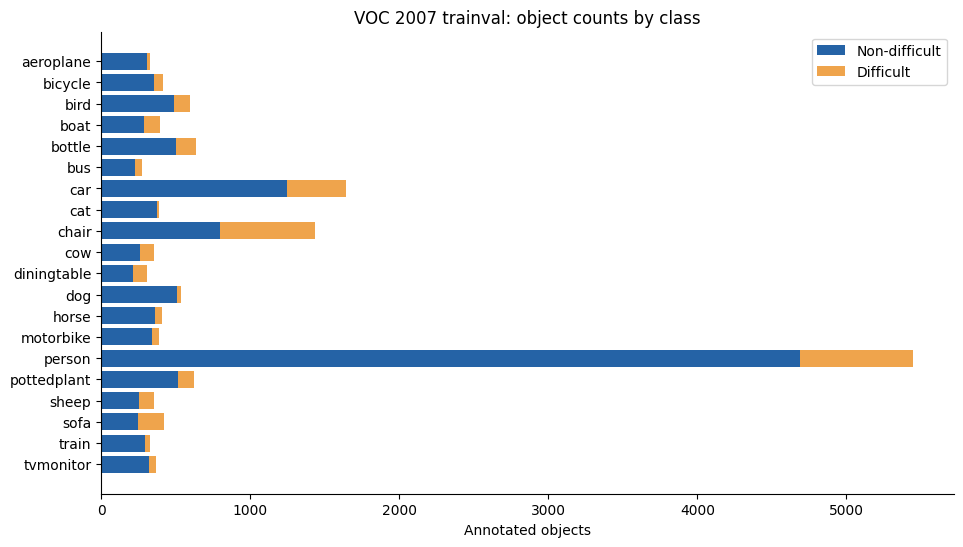

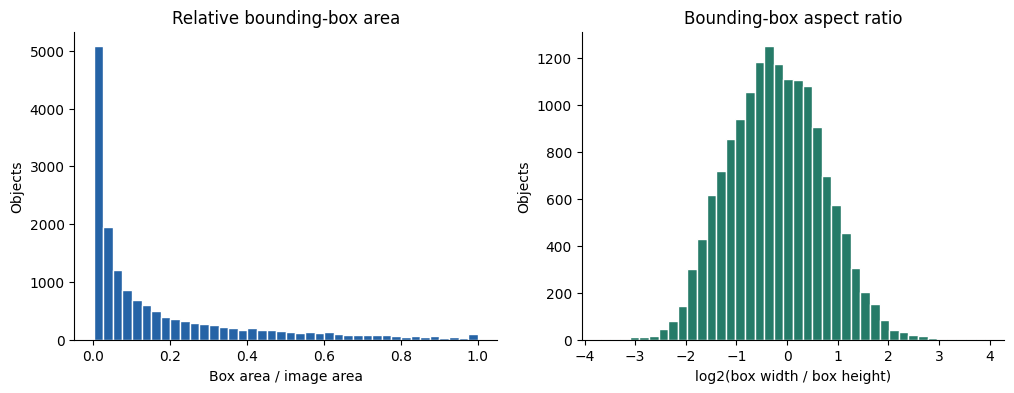

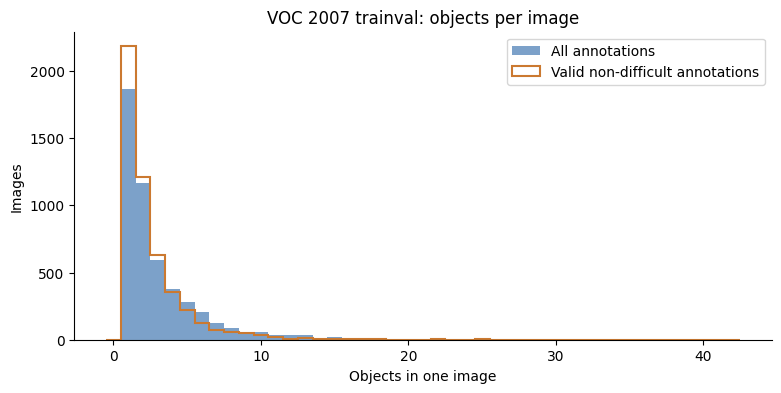

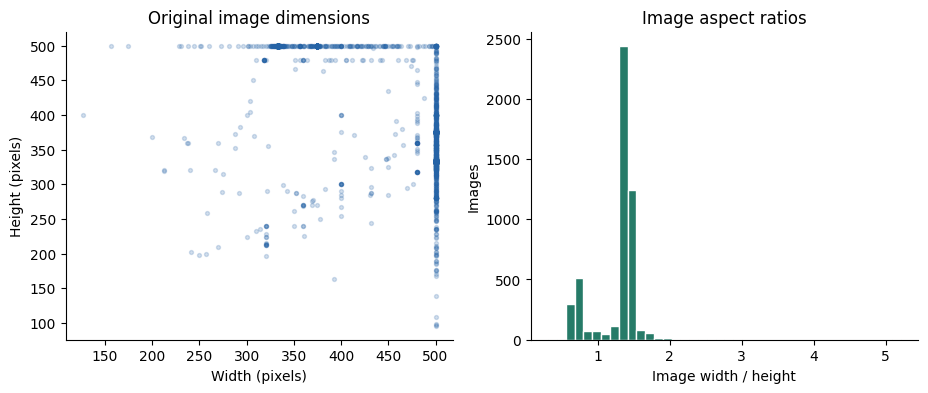

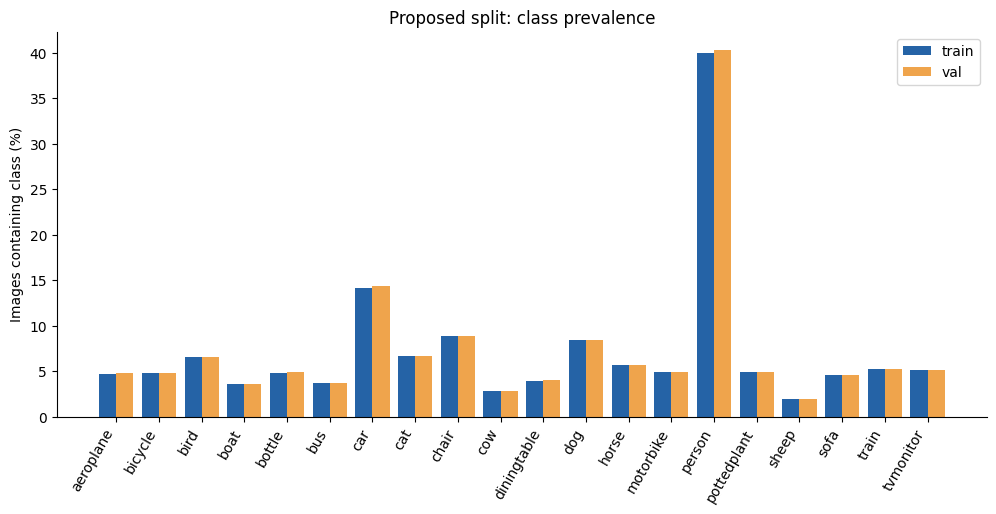

In [7]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
def save_figure(fig, filename):
    fig.savefig(OUT / "figures" / filename, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

full_class = class_counts_df[class_counts_df.split == "trainval"].set_index("class_name").loc[CLASSES]
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(CLASSES, full_class.objects_non_difficult, label="Non-difficult", color="#2563a6")
ax.barh(CLASSES, full_class.objects_difficult, left=full_class.objects_non_difficult,
        label="Difficult", color="#efa44c")
ax.invert_yaxis()
ax.set(xlabel="Annotated objects", title="VOC 2007 trainval: object counts by class")
ax.legend()
save_figure(fig, "class_distribution.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(geometry.relative_box_area, bins=40, color="#2563a6", edgecolor="white")
axes[0].set(xlabel="Box area / image area", ylabel="Objects", title="Relative bounding-box area")
axes[1].hist(np.log2(geometry.box_aspect_ratio), bins=40, color="#267b68", edgecolor="white")
axes[1].set(xlabel="log2(box width / box height)", ylabel="Objects", title="Bounding-box aspect ratio")
save_figure(fig, "bbox_size_distribution.png")

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(0, int(images_df.objects_all.max()) + 2) - 0.5
ax.hist(images_df.objects_all, bins=bins, alpha=0.6, label="All annotations", color="#2563a6")
ax.hist(images_df.objects_usable_non_difficult, bins=bins, histtype="step", linewidth=1.5,
        label="Valid non-difficult annotations", color="#cb7930")
ax.set(xlabel="Objects in one image", ylabel="Images", title="VOC 2007 trainval: objects per image")
ax.legend()
save_figure(fig, "objects_per_image.png")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(images_df.width, images_df.height, s=8, alpha=0.2, color="#2563a6")
axes[0].set(xlabel="Width (pixels)", ylabel="Height (pixels)", title="Original image dimensions")
axes[1].hist(images_df.image_aspect_ratio, bins=40, color="#267b68", edgecolor="white")
axes[1].set(xlabel="Image width / height", ylabel="Images", title="Image aspect ratios")
save_figure(fig, "image_dimensions.png")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CLASSES))
for offset, split, color in [(-0.2, "train", "#2563a6"), (0.2, "val", "#efa44c")]:
    part = class_counts_df[class_counts_df.split == split].set_index("class_name").loc[CLASSES]
    denominator = len(train_ids) if split == "train" else len(val_ids)
    ax.bar(x + offset, 100 * part.images_with_usable_non_difficult_class / denominator,
           width=0.4, label=split, color=color)
ax.set_xticks(x, CLASSES, rotation=60, ha="right")
ax.set(ylabel="Images containing class (%)", title="Proposed split: class prevalence")
ax.legend()
save_figure(fig, "split_class_prevalence.png")


## 7. Inspect ground-truth boxes and duplicate candidates

The random sample is reproducible with seed 42. Dashed boxes have the difficult flag.
These are labels from the dataset, not correct/incorrect model predictions.
Inspect more images by changing PREVIEW_IMAGE_IDS to a list of IDs from the CSV files.


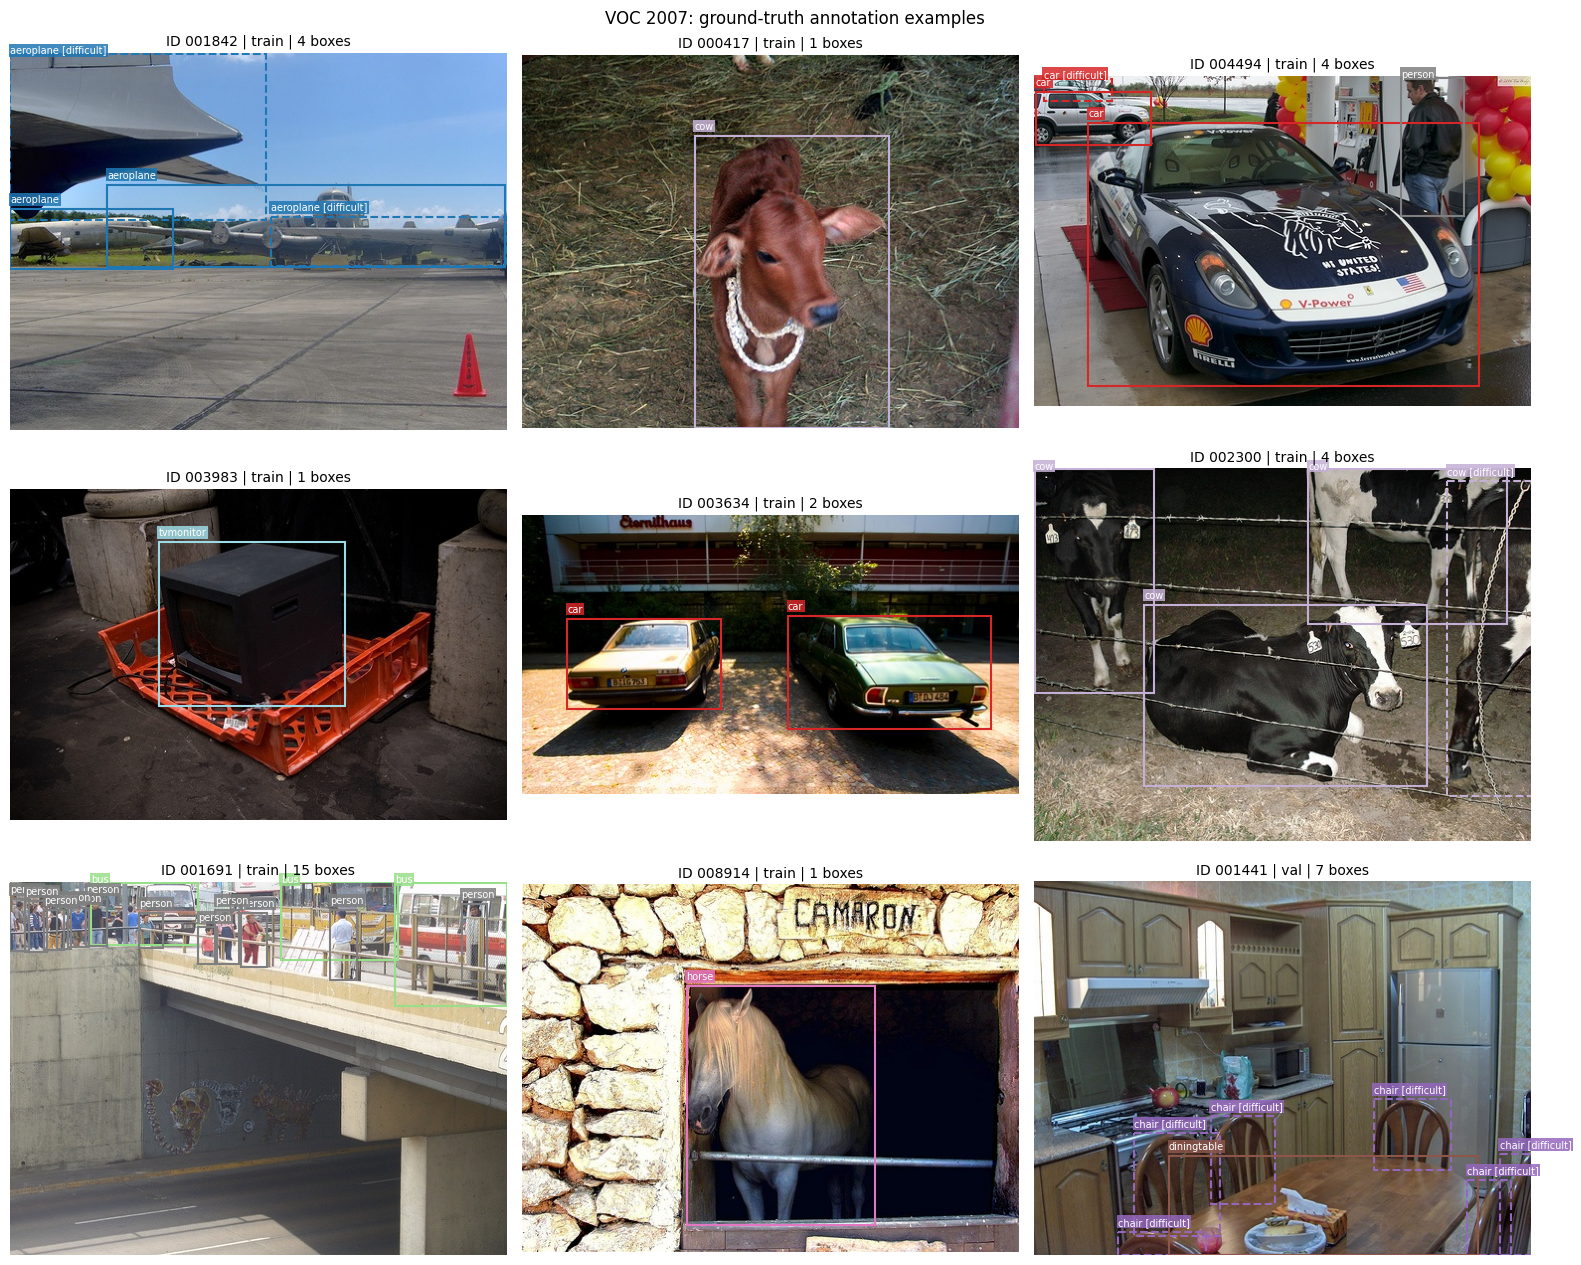

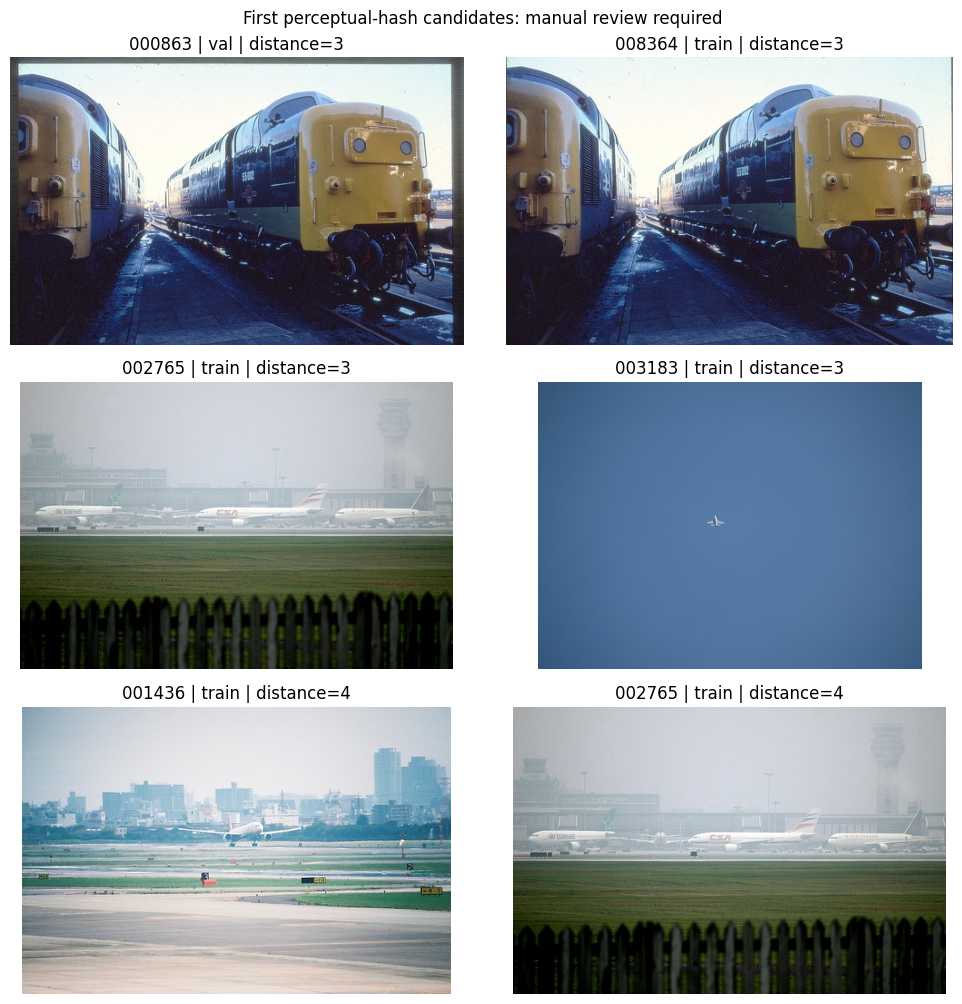

Review the images before writing your interpretation.


In [8]:
PREVIEW_IMAGE_IDS = random.Random(SEED).sample(trainval_ids, min(9, len(trainval_ids)))
def draw_annotations(ax, image_id):
    with Image.open(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") as image:
        ax.imshow(image.convert("RGB"))
    part = objects_df[(objects_df.image_id == image_id) & objects_df.valid_box]
    colors = plt.get_cmap("tab20")
    for row in part.itertuples():
        color = colors((CLASS_TO_ID.get(row.class_name, 1) - 1) % 20)
        ax.add_patch(Rectangle((row.xmin - 1, row.ymin - 1), row.box_width, row.box_height,
                              fill=False, edgecolor=color, linewidth=1.5,
                              linestyle="--" if row.difficult else "-"))
        label = row.class_name + (" [difficult]" if row.difficult else "")
        ax.text(row.xmin - 1, max(0, row.ymin - 8), label, fontsize=7, color="white",
                bbox={"facecolor": color, "alpha": 0.85, "pad": 1, "edgecolor": "none"})
    ax.set_title(f"ID {image_id} | {split_lookup[image_id]} | {len(part)} boxes", fontsize=10)
    ax.axis("off")

fig, axes = plt.subplots(math.ceil(len(PREVIEW_IMAGE_IDS) / 3), 3, figsize=(16, 13), squeeze=False)
for ax in axes.flat:
    ax.axis("off")
for ax, image_id in zip(axes.flat, PREVIEW_IMAGE_IDS):
    draw_annotations(ax, image_id)
fig.suptitle("VOC 2007: ground-truth annotation examples")
fig.tight_layout()
save_figure(fig, "ground_truth_examples.png")
(OUT / "example_image_ids.json").write_text(json.dumps(PREVIEW_IMAGE_IDS, indent=2), encoding="utf-8")

if len(candidates_df):
    selected = candidates_df.head(6)
    fig, axes = plt.subplots(len(selected), 2, figsize=(10, 3.4 * len(selected)), squeeze=False)
    for row_axes, pair in zip(axes, selected.itertuples()):
        for ax, image_id in zip(row_axes, [pair.image_id_a, pair.image_id_b]):
            with Image.open(VOC_ROOT / "JPEGImages" / f"{image_id}.jpg") as image:
                ax.imshow(image.convert("RGB"))
            ax.set_title(f"{image_id} | {split_lookup[image_id]} | distance={pair.dhash_distance}")
            ax.axis("off")
    fig.suptitle("First perceptual-hash candidates: manual review required")
    fig.tight_layout()
    save_figure(fig, "near_duplicate_candidates_preview.png")
print("Review the images before writing your interpretation.")


## 8. Save a factual summary and an editable interpretation template

Only values computed above are inserted automatically. Write your interpretation after inspecting
the tables and images. Do not replace missing model results with expected values.
Any comparison with the publisher must use the same object-count definition; the notebook exports
all, difficult, non-difficult and valid non-difficult counts separately.


In [9]:
summary = {
    "run_id": RUN_ID, "dataset": "PASCAL VOC 2007", "release": ARCHIVE_NAME,
    "data_scope": "official trainval only",
    "split_method": "Multi-Label Iterative Group Stratified Split (using iterative-stratification)",
    "seed": SEED, "target_train_images": target_train_count,
    "actual_train_images": len(train_ids), "actual_validation_images": len(val_ids),
    "official_test_status": "untouched; no results or overlap audit in this run",
    "split_summary": split_summary_df.to_dict("records"),
    "valid_box_relative_area_median": float(geometry.relative_box_area.median()),
    "valid_box_relative_area_p10": float(geometry.relative_box_area.quantile(0.10)),
    "valid_box_relative_area_p90": float(geometry.relative_box_area.quantile(0.90)),
    "truncated_objects": int(objects_df.truncated.eq(1).sum()),
    "annotation_issue_count": len(issues_df),
    "exact_duplicate_groups": int(duplicate_images.pixel_sha256.nunique()),
    "near_duplicate_candidate_count": len(candidates_df),
    "manual_review": "pending", "instructor_approval": "not recorded",
    "model_results": "not applicable: this is an EDA-only run",
}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
ranked = full_class.sort_values("objects_usable_non_difficult", ascending=False)
top_name, bottom_name = ranked.index[0], ranked.index[-1]
full_row = split_summary_df[split_summary_df.split == "trainval"].iloc[0]
lines = [
    "# Preliminary EDA notes — review before submission", "",
    f"Run ID: {RUN_ID}", "Prepared for review by Nguyễn Hữu Cầu and Trần Gia Lâm.", "",
    "## Facts computed by this run",
    f"- Successfully decoded images: {len(images_df)}.",
    f"- XML object entries (including difficult): {len(objects_df)}.",
    f"- Difficult object entries: {int(objects_df.difficult.eq(1).sum())}.",
    f"- Valid non-difficult objects: {int(objects_df.usable_non_difficult.sum())}.",
    f"- Proposed train / validation images: {len(train_ids)} / {len(val_ids)}.",
    f"- Valid non-difficult training objects: {int(train_row.objects_usable_non_difficult)}.",
    f"- Most frequent class by valid non-difficult objects: {top_name} ({int(ranked.iloc[0].objects_usable_non_difficult)}).",
    f"- Least frequent class by the same definition: {bottom_name} ({int(ranked.iloc[-1].objects_usable_non_difficult)}).",
    f"- Objects per image: mean {full_row.objects_per_image_mean:.3f}, median {full_row.objects_per_image_median:.1f}, maximum {int(full_row.objects_per_image_max)}.",
    f"- Median relative area of valid boxes: {geometry.relative_box_area.median():.6f}.",
    f"- Annotation issues: {len(issues_df)}; perceptual-hash candidates: {len(candidates_df)}.",
    "", "## Interpretation to be written by Cầu",
    "1. Class imbalance: cite class_counts.csv and explain the likely evaluation concern.",
    "2. Box sizes: cite bbox_summary.csv and explain the possible effect of resizing on small objects.",
    "3. Multiple objects: explain the objects-per-image distribution.",
    "4. Annotation quality: state exactly which sample IDs were reviewed and what was observed.",
    "5. Split review: discuss class coverage, duplicate candidates, and remaining leakage checks.",
    "6. Modeling implications: propose changes as hypotheses; do not claim measured improvements.",
    "", "## Review record",
    "- Reviewed by: [fill after review]",
    "- Review date: [fill]",
    "- Candidate-pair decisions / unresolved issues: [fill]",
    "- Student edits and verification of assisted notebook/text: [fill]",
    "", "The split remains proposed until review. No model was trained. No instructor approval is claimed.",
    "", "## Sources",
] + [f"- {key}: {url}" for key, url in SOURCES.items()]
(OUT / "EDA_NOTES_TO_COMPLETE.md").write_text("\n".join(lines) + "\n", encoding="utf-8")
print("Saved summary.json, quality_checks.json and EDA_NOTES_TO_COMPLETE.md")


Saved summary.json, quality_checks.json and EDA_NOTES_TO_COMPLETE.md


## 9. Export the handoff ZIP

Return: (1) the ZIP below; (2) this notebook downloaded with its outputs; (3) the completed EDA notes.
The ZIP contains tables, figures, split IDs and metadata. It does not contain the original dataset.
The exported split is a proposal, not an approval record.


In [10]:
import zipfile

handoff_readme = [
    "G-M10 — A2 preliminary EDA run", f"Run ID: {RUN_ID}", "",
    "Read summary.json and quality_checks.json first.",
    "Complete EDA_NOTES_TO_COMPLETE.md after checking the figures and tables.",
    "Near-duplicate pairs are candidates; review them manually.",
    "Test-set overlap has not been checked in this EDA-only run.",
    "No training results or approval are claimed.",
    "Save and send the executed notebook separately; it is not captured automatically by this ZIP.",
]
(OUT / "README.txt").write_text("\n".join(handoff_readme) + "\n", encoding="utf-8")
manifest = {str(p.relative_to(OUT)): file_digest(p) for p in sorted(OUT.rglob("*")) if p.is_file()}
(OUT / "file_sha256.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
result_zip = BASE / f"G-M10_A2_Cau_EDA_{RUN_ID}.zip"
with zipfile.ZipFile(result_zip, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(OUT.rglob("*")):
        if path.is_file():
            archive.write(path, Path("outputs/a2_eda") / RUN_ID / path.relative_to(OUT))
print("Results ZIP:", result_zip)
print("Also use File > Download > Download .ipynb to save this notebook with outputs.")
try:
    from google.colab import files
except ImportError:
    print("Outside Colab: copy the ZIP from the path above.")
else:
    files.download(str(result_zip))


Results ZIP: /content/G-M10_A2_Cau_EDA_20261006T225426_686818Z.zip
Also use File > Download > Download .ipynb to save this notebook with outputs.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Sources and assistance record

- [VOC 2007 publisher](https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/)
- [Published statistics](https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/dbstats.html)
- [Annotation and evaluation documentation](https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/htmldoc/index.html)
- [Torchvision archive URL and checksum](https://docs.pytorch.org/vision/stable/_modules/torchvision/datasets/voc.html)

ChatGPT assisted Lâm with the EDA plan and notebook preparation. Cầu is assigned to run and inspect
the notebook; Lâm is assigned to review the proposal. These assignments do not imply completed verification.
Record the actual edits, run evidence and reviewers in the project's AI_USAGE.md before submission.
